In [1]:
import sys,copy,os,inspect
if hasattr(sys.modules[__name__], '__file__'):
    _file_name = __file__
else:
    _file_name = inspect.getfile(inspect.currentframe())
CURRENT_FILE_PATH = os.path.dirname(_file_name)
sys.path.append(os.getcwd()+"/../neuronVis")

import IONData,Scene
import NeuronProcess
import matplotlib

import matplotlib.pyplot as plt
matplotlib.use('module://matplotlib_inline.backend_inline')
%matplotlib inline

iondata = IONData.IONData()

def regionSymmetry(properties):
    leftProject = properties['projectleftregion']
    if 'unknow' in leftProject:
        del(leftProject['unknow'])
    leftProject = {k: v for k, v in leftProject.items() if v > 0}

    rightProject = properties['projectrightregion']
    if 'unknow' in rightProject:
        del(rightProject['unknow'])
    rightProject = {k: v for k, v in rightProject.items() if v > 0}

    setLeft = set(leftProject)
    setRight=set(rightProject)
    bothregion = setLeft & setRight
    allregion =setLeft | setRight

    return len(bothregion)/len(allregion)
def isBilateral(neuron):
    properties = iondata.getNeuronPropertyByID(neuron['sampleid'],neuron['name'])
    leftProject = properties['projectleftregion']
    rightProject = properties['projectrightregion']
    leftCount=0
    for region,length in leftProject.items():
        if region!='unknow' and length>0:
            leftCount+=1
            break
    rightCount=0
    for region,length in rightProject.items():
        if region!='unknow' and length>0:
            rightCount+=1
            break
    if leftCount >0 and rightCount>0:
        return True,regionSymmetry(properties)
    else:
        return False,0



In [ ]:
import Visual as nv
import json
neuronvis = nv.neuronVis(renderModel=1)
#In[0] single neuron symmetry
neurons =[]
for i in range(1,15):
    scenefile='../resource/scene/cluster'+str(i)+'_spcd20220628_spcd.nv'
    neurons+= Scene.scene2List(scenefile)
bilateralNeurons=[]
color = ['c', 'b', 'g', 'r', 'm', 'y', 'k', 'w']
count=0
neuronvis = nv.neuronVis(renderModel=0)
neuronvis.render.setView()
neuronvis.render.setBackgroundColor((0.0,0.20,0.5,1.0))
for neuron in neurons:
    res = isBilateral(neuron)
    if res[0]:
        bilateralNeurons.append([neuron,res[1]])
        plt.scatter(count, res[1], c=color[1], edgecolors='r')
        count+=1
    if res[1]>0.25:
        neuronvis.addNeuronByID(neuron['sampleid'],neuron['name'],color=[1,1,1])
        neuronvis.render.savepng('../resource/symmetry/'+neuron['sampleid']+ neuron['name']+str(res[1])+'.png')
        neuronvis.clear()
plt.show()
# print(bilateralNeurons)

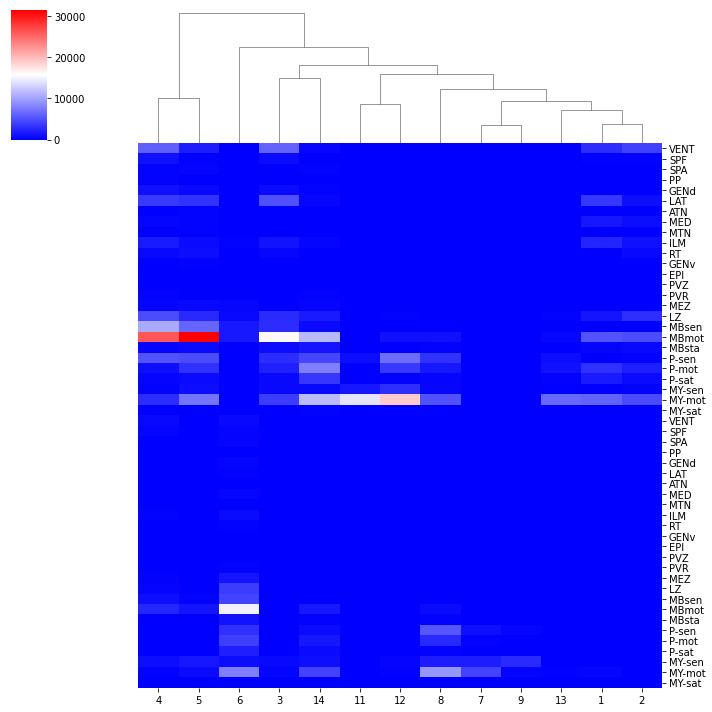

In [2]:

import Visual as nv
import json
#In[1] subtype symmetry
import BrainRegion as BR 
import pandas as pd
import seaborn	as sns
import matplotlib.pyplot as plt
import numpy as np
br = BR.BrainRegion()
br.praseJson()
# region=[['VENT','SPF','SPA','PP','GENd','LAT','ATN','MED','MTN','ILM','RT','GENv','EPI'],['PVZ','PVR','MEZ','LZ'],['MBsen','MBmot','MBsta'],['P-sen','P-mot','P-sat','MY-sen','MY-mot','MY-sat']]
region=['VENT','SPF','SPA','PP','GENd','LAT','ATN','MED','MTN','ILM','RT','GENv','EPI','PVZ','PVR','MEZ','LZ','MBsen','MBmot','MBsta','P-sen','P-mot','P-sat','MY-sen','MY-mot','MY-sat']
df = pd.DataFrame()
neurons =[]
clusterBilateral={}
for i in range(1,15):
    if i==10:
        continue
    scenefile='../resource/scene/cluster'+str(i)+'_spcd20220628_spcd.nv'
    neurons= Scene.scene2List(scenefile)
    propmean=None
    bilateralCount=0
    for neuron in neurons:
        # if not isBilateral(neuron)[0]:
        #     continue
        bilateralCount+=1
        brproperty=BR.RegionProperty(copy.deepcopy(br))
        brpropertyLeft=BR.RegionProperty(copy.deepcopy(br))
        brpropertyRight=BR.RegionProperty(copy.deepcopy(br))
        property = iondata.getNeuronPropertyByID(neuron['sampleid'], neuron['name'])
        brproperty.setProperty(property['projectregion'])
        brpropertyLeft.setProperty(property['projectleftregion'])
        brpropertyRight.setProperty(property['projectrightregion'])
        prop=[]
        for reg in region:
            leftLength = brpropertyLeft.getSumProperty(reg)
            prop.append(leftLength)
        for reg in region:
            rightLength = brpropertyRight.getSumProperty(reg)
            prop.append(rightLength)
        if propmean is None:
            propmean=np.array(prop)
        else:
            propmean+=np.array(prop)
    if bilateralCount:
        propmean = propmean/bilateralCount
        clusterBilateral[i]=bilateralCount
        df[str(i)]=propmean
df.index=pd.Series(region+region)
df.to_csv("../resource/symmetry.csv")
sns.clustermap(df, fmt="d",metric='euclidean', cmap='bwr', method='average',xticklabels=True,yticklabels=True,row_cluster=False)
plt.show()
pass

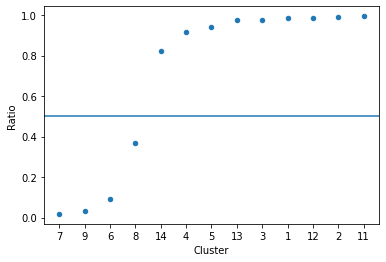

In [3]:
leftsum = df[:][0:26].sum()
allsum = df[:][:].sum()
ratio= leftsum/allsum
sortedRatio = ratio.sort_values()
ratiodf = pd.DataFrame(sortedRatio)
ratiodf =ratiodf.reset_index()
ratiodf.columns=['Cluster','Ratio']

ratiodf.plot.scatter(x='Cluster',y='Ratio')
plt.axhline(0.5)
# ratiodf

<AxesSubplot:xlabel='Left', ylabel='Right'>

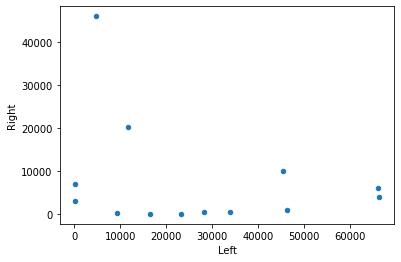

In [4]:
leftsum = df[:][0:26].sum()
rightsum = df[:][26:52].sum()
leftrightdf = pd.concat([leftsum, rightsum], axis=1)
leftrightdf.columns=['Left','Right']

leftrightdf.plot.scatter(x='Left',y='Right')


Text(69.0, 0.5, 'Regions')

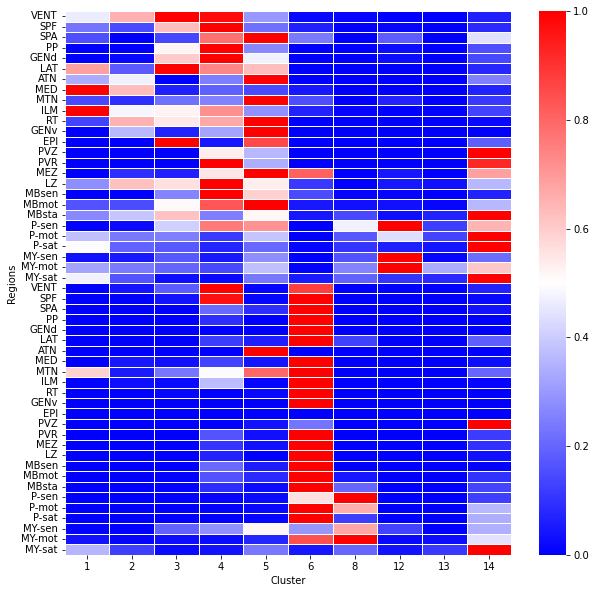

In [5]:

df1 = df.apply(lambda x: x/x.max() if x.max()>0 else x, axis=1)
for index in df1.columns:
    if df1[index][0:26].sum()<0.1 or df1[index][26:52].sum()<0.1:
        df1 = df1.drop([index], axis=1)

# df1=(np.log2(df/10+1))
# df1=df
# print(df)
# fig = sns.clustermap(df1, fmt="d",metric='euclidean',cmap='bwr',  method='average',xticklabels=True,yticklabels=True,row_cluster=False)
fig,ax = plt.subplots(figsize=(10,10))
sns.heatmap(df1, fmt="d",cmap='bwr',linewidth=1)
plt.xlabel('Cluster')
plt.ylabel('Regions')

['1', '2', '3', '4', '5', '6', '8', '12', '13', '14'] [0.02457837418775177, 0.1813922891685099, 0.07673341313940688, 0.3581500461117903, 0.29908413376959564, 0.21096562339015126, 0.9073502773169771, 0.580133329171824, 0.3081818750056152, 0.644832051551004]


Text(0, 0.5, 'Spearman’s rank correlation coefficient')

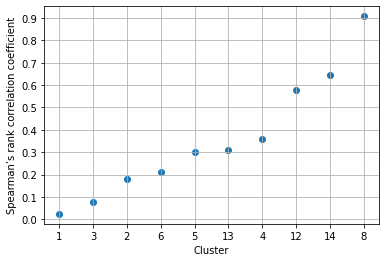

In [6]:
from tokenize import Name
import scipy.stats as stats
def ComputeRs(a, b):
    aa = np.column_stack((a, b))
    # rank的方式有很多种，这里使用的average的方式
    aa_ranked = np.apply_along_axis(stats.rankdata, 0, aa)
    rs = np.corrcoef(aa, rowvar=0)
    return rs[1, 0]

data = np.array(df1)

index=[]
rs =[]
for i in range(data.shape[1]):
    # print(df1.columns[i],"  ")
    left = data[0:26,i]
    right = data[26:52,i]

    # a_z_idx = [~(left != 0)]
    # b_z_idx = [~(right != 0)]
    # ab_z_idx = a_z_idx[0] & b_z_idx[0]
    # left= left[~ab_z_idx]
    # right = right[~ab_z_idx]
    
    # print('delete',left,right)
    # print(np.mean(np.multiply((left-np.mean(left)),(right-np.mean(right))))/(np.std(left)*np.std(right)))
    # print("ncc",np.mean(np.multiply(left,right))/(np.linalg.norm(left)*np.linalg.norm(right)))
    # print(ComputeRs(left.tolist(), right.tolist()))
    index.append(df1.columns[i])
    rs.append(ComputeRs(left.tolist(), right.tolist()))
    # print(i+1,coef, p)

df2 = pd.DataFrame({'name':index, 'rs':rs})
print(index,rs)
# plt.xticks(x,index)
# plt.scatter(x, rs)
df3 = df2.sort_values(by='rs')
x=[]
index=np.array(df3['name'])
rs =np.array(df3['rs'])
for i in range(len(df3)):
    x.append(i)
fig = plt.figure()
ax = fig.gca()
ax.set_xticks(np.arange(0, 13, 1))
ax.set_yticks(np.arange(0, 1., 0.1))
plt.xticks(x,index)
plt.grid()
plt.scatter(x, rs)
plt.xlabel('Cluster')
plt.ylabel('Spearman’s rank correlation coefficient')


